# Product Category Classifier
Cilj ovog projekta je da napravim model koji na osnovu naziva proizvoda predvidja njegovu kategoriju

In [1]:
from google.colab import files
uploaded=files.upload()

Saving products.csv to products.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

## Ucitavanje i istrazivanje podataka

In [3]:
podaci=pd.read_csv('products.csv')
print("Prvih 5 redova:")
print(podaci.head())

print("\nBroj redova i kolona:",podaci.shape)
print("\nNazivi kolona:")
print(podaci.columns.tolist())
print("\nBroj nedostajucih vrijednosti po koloni:")
print(podaci.isnull().sum())

Prvih 5 redova:
   product ID                                      Product Title  Merchant ID  \
0           1                    apple iphone 8 plus 64gb silver            1   
1           2                apple iphone 8 plus 64 gb spacegrau            2   
2           3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            3   
3           4                apple iphone 8 plus 64gb space grey            4   
4           5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            5   

   Category Label _Product Code  Number_of_Views  Merchant Rating  \
0   Mobile Phones    QA-2276-XC            860.0              2.5   
1   Mobile Phones    KA-2501-QO           3772.0              4.8   
2   Mobile Phones    FP-8086-IE           3092.0              3.9   
3   Mobile Phones    YI-0086-US            466.0              3.4   
4   Mobile Phones    NZ-3586-WP           4426.0              1.6   

   Listing Date    
0       5/10/2024  
1      12/31/2024  
2      11/10/2024  
3 

## Ciscenje naziva kolona
Nazivi kolona imaju nepotrebne razmake i znak donje crte na pocetku,sto otezava rad.Prvo ih cistim i standardizujem.

In [6]:
print("Nazivi kolona prije ciscenja:")
print(podaci.columns.tolist())

podaci.columns=podaci.columns.str.strip()
podaci.columns=podaci.columns.str.lstrip('_')

print("\nNazivi kolona poslije ciscenja:")
print(podaci.columns.tolist())

Nazivi kolona prije ciscenja:
['product ID', 'Product Title', 'Merchant ID', 'Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']

Nazivi kolona poslije ciscenja:
['product ID', 'Product Title', 'Merchant ID', 'Category Label', 'Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']


In [7]:
print("Sve razlicite vrijednosti u koloni Category Label:")
print(podaci['Category Label'].value_counts())

Sve razlicite vrijednosti u koloni Category Label:
Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: int64


## Standardizacija kategorija
Kolona Category Label sadrzi iste kategorije napisane na dva razlicita nacina.Standardizujem ih tako da svaka kategorija ima samo jedan naziv.

In [12]:
zamjene_kategorija={
    'fridge':'Fridges',
    "CPU":"CPUs",
    "Mobile Phone":"Mobile Phones"
}
podaci["Category Label"]=podaci["Category Label"].replace(zamjene_kategorija)
print("Vrijednosti u Category Label nakon standardizacije:")
print(podaci['Category Label'].value_counts())

Vrijednosti u Category Label nakon standardizacije:
Category Label
Fridge Freezers     5495
Mobile Phones       4075
Washing Machines    4036
CPUs                3855
Fridges             3580
TVs                 3564
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
Name: count, dtype: int64


## Uklanjanje praznih vrijednosti
Za treniranje modela su mi kljucne kolone Product Title i Categroy Label.Redove koima fali bilo koja od te dvije vrijednosti uklanjam,jer ih ne mogu koristiti za treniranje.

In [19]:
print("Broj redova prije ciscenja:",len(podaci))
podaci=podaci.dropna(subset=["Product Title","Category Label"]).copy()
print("Broj redova poslije ciscenja:",len(podaci))

Broj redova prije ciscenja: 35096
Broj redova poslije ciscenja: 35096


## Inzinjering karakteristika
Osim samog teksta naziva proizvoda,mogu izvuci dodatne karakteristike koje bi mogle pomoci modelu da bolje prepozna kategoriju:
- broj rijeci u naslovu,
- broj karaktera u naslovu,
- da li naslov sadrzi bar jedan broj,
- duzina najduze rijeci u naslovu

In [20]:
podaci['broj_rijeci']=podaci['Product Title'].str.split().str.len()
podaci['broj_karaktera']=podaci["Product Title"].str.len()
podaci["ima_broj"]=podaci["Product Title"].str.contains(r'\d')
podaci["ima_broj"]=podaci["ima_broj"].astype(int)

def duzina_najduze_rijeci(tekst):
      rijeci=tekst.split()
      najduza=0
      for rijec in rijeci:
        if len(rijec)>najduza:
          najduza=len(rijec)
      return najduza

podaci['duzina_najduze_rijeci']=podaci['Product Title'].apply(duzina_najduze_rijeci)
print(podaci[['Product Title','broj_rijeci','broj_karaktera','ima_broj','duzina_najduze_rijeci']].head())


                                       Product Title  broj_rijeci  \
0                    apple iphone 8 plus 64gb silver            6   
1                apple iphone 8 plus 64 gb spacegrau            7   
2  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...           13   
3                apple iphone 8 plus 64gb space grey            7   
4  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...           11   

   broj_karaktera  ima_broj  duzina_najduze_rijeci  
0              31         1                      6  
1              35         1                      9  
2              70         1                     10  
3              35         1                      6  
4              54         1                      8  


## Podijela podataka na trening i test skup
Podijelit cu podatke na trening i test skup.Koristit cu odnos 80:20,uz stratify=y da ocuvam slican odnos kategorija u oba skupa.

In [22]:
x=podaci['Product Title']
y=podaci['Category Label']

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)
print("Broj proizvoda u trening skupu:",len(x_train))
print("Broj proizvoda u test skupu:",len(x_test))

Broj proizvoda u trening skupu: 28076
Broj proizvoda u test skupu: 7020


## Vektorizacija teksta
Koristim TfidfVectorizer da pretvorim naziv proizvoda u brojeve.Za sada koristim samo tekst naslova-u sljedecem kroaku cu probati da li dodatne karakteristike poboljsavaju rezultat.

In [24]:
vektorizator=TfidfVectorizer()
x_train_vek=vektorizator.fit_transform(x_train)
x_test_vek=vektorizator.transform(x_test)

print("Oblik trening podataka nakon vektorizacije:",x_train_vek.shape)

Oblik trening podataka nakon vektorizacije: (28076, 17381)


## Testiranje i poredjenje vise modela
Pravim rijecnik sa cetiri razlicita modela,treniram svaki i uporedjujem njihove performanse da izaberem najbolji.

In [26]:
modeli={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Naive Bayes":MultinomialNB(),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Linear SVC":LinearSVC()
}
predikcije={}
for ime_modela in modeli:
  model=modeli[ime_modela]
  model.fit(x_train_vek,y_train)
  predikcije[ime_modela]=model.predict(x_test_vek)
  print(ime_modela,'- treniran')

Logistic Regression - treniran
Naive Bayes - treniran
Decision Tree - treniran
Linear SVC - treniran


## Evaluacija performansi
Za svaki model prikazujem tacnost,klasifikacioni izvjestaj i matricu zabune kao heatmap.

----------------------------------------
Logistic Regression
----------------------------------------
Tacnost: 0.96

Klasifikacioni izvjestaj:
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      1.00       766
 Digital Cameras       0.99      0.99      0.99       538
     Dishwashers       0.93      0.97      0.95       681
        Freezers       0.99      0.93      0.96       440
 Fridge Freezers       0.96      0.93      0.94      1094
         Fridges       0.89      0.91      0.90       712
      Microwaves       0.99      0.94      0.97       466
   Mobile Phones       0.97      0.99      0.98       812
             TVs       0.97      0.99      0.98       708
Washing Machines       0.94      0.95      0.95       803

        accuracy                           0.96      7020
       macro avg       0.96      0.96      0.96      7020
    weighted avg       0.96      0.96      0.96      7020



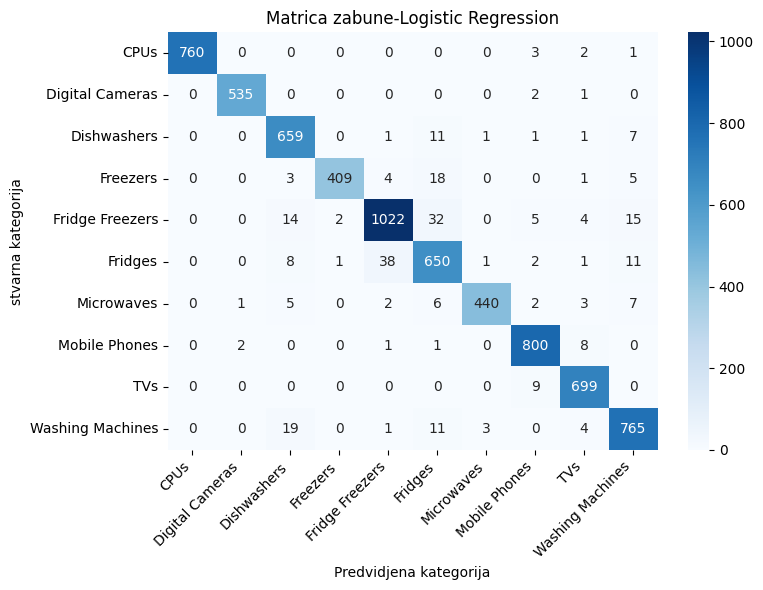

----------------------------------------
Naive Bayes
----------------------------------------
Tacnost: 0.9396

Klasifikacioni izvjestaj:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       766
 Digital Cameras       0.99      0.99      0.99       538
     Dishwashers       0.98      0.96      0.97       681
        Freezers       1.00      0.54      0.70       440
 Fridge Freezers       0.78      0.98      0.87      1094
         Fridges       0.91      0.86      0.88       712
      Microwaves       0.99      0.97      0.98       466
   Mobile Phones       0.99      0.99      0.99       812
             TVs       0.98      0.99      0.99       708
Washing Machines       0.97      0.96      0.97       803

        accuracy                           0.94      7020
       macro avg       0.96      0.92      0.93      7020
    weighted avg       0.95      0.94      0.94      7020



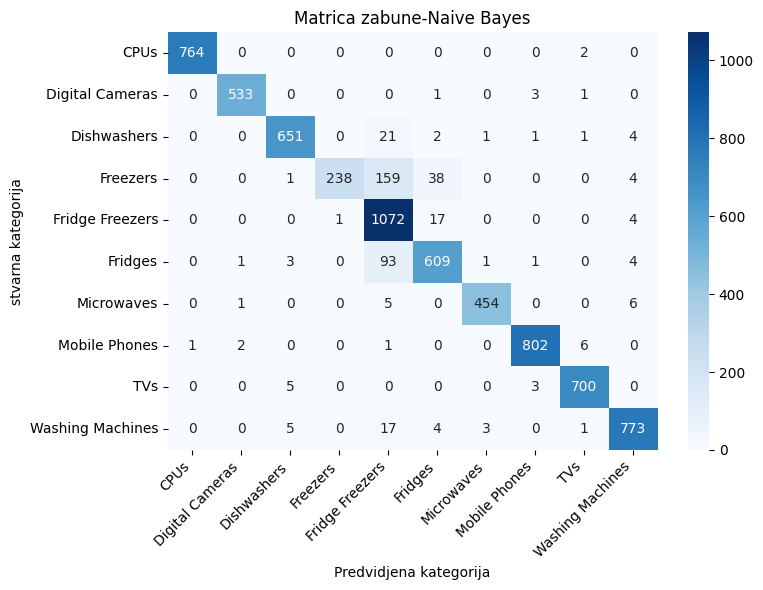

----------------------------------------
Decision Tree
----------------------------------------
Tacnost: 0.9397

Klasifikacioni izvjestaj:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       766
 Digital Cameras       1.00      0.96      0.98       538
     Dishwashers       0.92      0.92      0.92       681
        Freezers       0.89      0.91      0.90       440
 Fridge Freezers       0.90      0.91      0.91      1094
         Fridges       0.87      0.87      0.87       712
      Microwaves       0.97      0.94      0.95       466
   Mobile Phones       0.95      0.98      0.96       812
             TVs       0.97      0.98      0.97       708
Washing Machines       0.96      0.92      0.94       803

        accuracy                           0.94      7020
       macro avg       0.94      0.94      0.94      7020
    weighted avg       0.94      0.94      0.94      7020



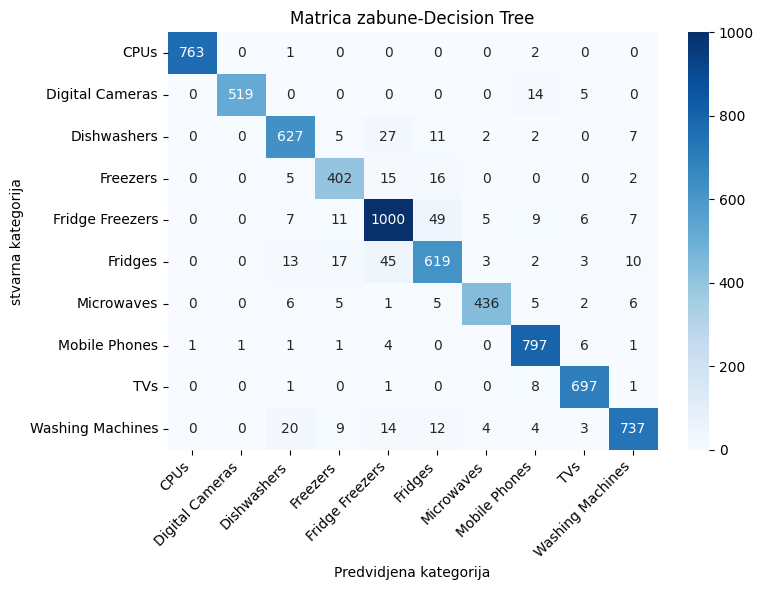

----------------------------------------
Linear SVC
----------------------------------------
Tacnost: 0.9721

Klasifikacioni izvjestaj:
                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       766
 Digital Cameras       1.00      1.00      1.00       538
     Dishwashers       0.95      0.98      0.96       681
        Freezers       0.98      0.97      0.97       440
 Fridge Freezers       0.97      0.95      0.96      1094
         Fridges       0.94      0.93      0.93       712
      Microwaves       0.99      0.97      0.98       466
   Mobile Phones       0.99      0.99      0.99       812
             TVs       0.97      1.00      0.98       708
Washing Machines       0.95      0.96      0.96       803

        accuracy                           0.97      7020
       macro avg       0.97      0.97      0.97      7020
    weighted avg       0.97      0.97      0.97      7020



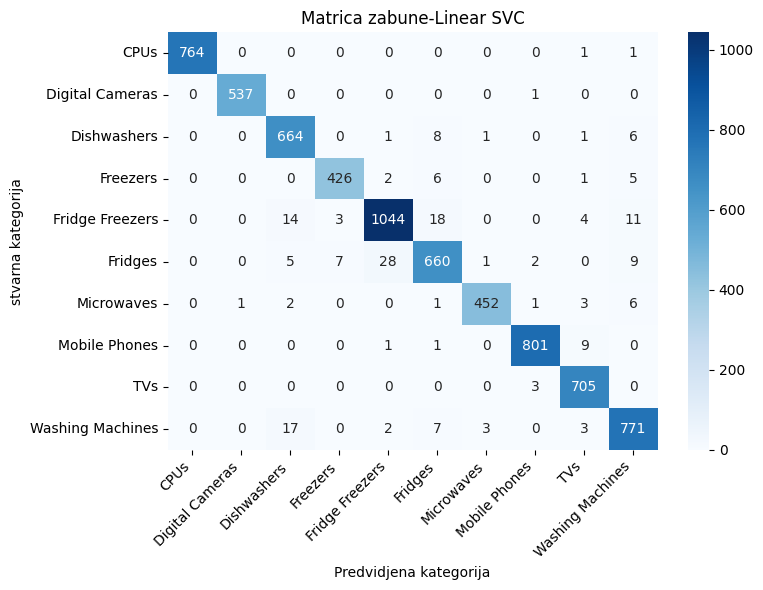

In [27]:
for ime_modela in modeli:
  pred=predikcije[ime_modela]
  print("-"*40)
  print(ime_modela)
  print("-"*40)
  acc=accuracy_score(y_test,pred)
  print("Tacnost:",round(acc,4))
  print("\nKlasifikacioni izvjestaj:")
  print(classification_report(y_test,pred))
  kategorije=sorted(y.unique())
  matrica=confusion_matrix(y_test,pred,labels=kategorije)
  plt.figure(figsize=(8,6))
  sns.heatmap(matrica,annot=True,fmt='d',cmap='Blues',
              xticklabels=kategorije,yticklabels=kategorije)
  plt.xlabel('Predvidjena kategorija')
  plt.ylabel("stvarna kategorija")
  plt.title(f'Matrica zabune-{ime_modela}')
  plt.xticks(rotation=45,ha='right')
  plt.tight_layout()
  plt.show()

## Zakljucak-izbor modela
Sva cetiri modela pokazuju solidne rezultate,ali Linear SVC je ubjedljivo najbolji sa tacnoscu od 97,21%.
Najvise gresaka svi modeli prave izmedju kateorija Fridges i Fridges Freezers(vjv jer su slicni proizvodi i imaju slicne rijeci u nazivu).
Naive Bayes ima najnizi odziv za kategoriju Freezers.
Za finalni model biram Linear SVC,jer nudi najbolji balans izmedju svih metrika.

## Treniranje i cuvanje finalnog modela
Za finalni model koji cu sacuvati,treniram Linear SVC i TfidfVectorizer nad svim podacima,jer zelim da model za stvarnu upotrebu koristi sto vise informacija koje imam.

In [30]:
finalni_vektorizator=TfidfVectorizer()
x_sve_vek=finalni_vektorizator.fit_transform(x)
finalni_model=LinearSVC()
finalni_model.fit(x_sve_vek,y)
print("Finalni model je istreniran.")
with open('model.pkl','wb')as fajl:
  pickle.dump(finalni_model,fajl)

with open('vektorizator.pkl','wb')as fajl:
  pickle.dump(finalni_vektorizator,fajl)

print("Model i vektorizator su sacuvani u .pkl fajlove.")

Finalni model je istreniran.
Model i vektorizator su sacuvani u .pkl fajlove.


## Rucno testiranje modela
Testiram finalni model na nekoliko naziva proizvoda datih u zadatku,da provjerim da li model daje ocekivane rezultate.

In [34]:
test_proizvodi=[
    "iphone 7 32gb gold",
    'plympus e m10 mark ili geh use silber',
    "kenwood k20mss15 solo",
    "bosch wap28390gb 8kg 1400 spin",
    "bosch serie 4 kgv39vl31g",
    'smeg sbs8004po'
]

for naziv in test_proizvodi:
  naziv_vek=finalni_vektorizator.transform([naziv])
  predikcija=finalni_model.predict(naziv_vek)
  print(naziv,"->",predikcija[0])

iphone 7 32gb gold -> Mobile Phones
plympus e m10 mark ili geh use silber -> Digital Cameras
kenwood k20mss15 solo -> Microwaves
bosch wap28390gb 8kg 1400 spin -> Washing Machines
bosch serie 4 kgv39vl31g -> Dishwashers
smeg sbs8004po -> Dishwashers


## Finalni zakljucak
Model prepoznaje tacno 4 od 6 test proizvoda.Dvije greske pokazuje ogranicenje modela,obje su pogresno kalsifikovane kao Dishwashers umjesto Fridge Freezers.Vjerovatno jer su oriizvodi bosch serie u nazivu najcesce masine za pranje sudja,pa model uci na osnovu te asocijacije,sto pokazcuje da model gleda obrasce rijeci,a ne stvarno znacenje proizvoda.